In [1]:
import pandas as pd
import numpy as np

In [3]:
# Customer Sign-Up Behaviour Analysis

# Project Overview
# This project analyses customer sign-up behaviour for a SaaS company called Rapid Scale.

#The goal is to audit the dataset for data quality issues and generate insights that help the marketing and onboarding teams improve acquisition strategies.

file_path = '../data/raw/customer_signups.csv'

In [4]:
df = pd.read_csv(file_path)
df.head()

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
0,CUST00000,Joshua Bryant,NaN,NaN,Instagram,NaN,basic,No,34,Female
1,CUST00001,Nicole Stewart,nicole1@example.com,02-01-24,LinkedIn,West,basic,Yes,29,Male
2,CUST00002,Rachel Allen,rachel2@example.com,03-01-24,Google,North,PREMIUM,Yes,34,Non-Binary
3,CUST00003,Zachary Sanchez,zachary3@mailhub.org,04-01-24,YouTube,NaN,Pro,No,40,Male
4,CUST00004,NaN,matthew4@mailhub.org,05-01-24,LinkedIn,West,Premium,No,25,Other


In [5]:
# Understand the Data Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       298 non-null    object
 1   name              291 non-null    object
 2   email             266 non-null    object
 3   signup_date       298 non-null    object
 4   source            291 non-null    object
 5   region            270 non-null    object
 6   plan_selected     292 non-null    object
 7   marketing_opt_in  290 non-null    object
 8   age               288 non-null    object
 9   gender            292 non-null    object
dtypes: object(10)
memory usage: 23.6+ KB


In [6]:
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")

C:\Users\mon12\AppData\Local\Temp\ipykernel_60844\3231550512.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")


In [7]:
# Data Cleaning
# In this step, I check for missing values, fix data types, standardise inconsistent text fields, and remove duplicate customer records.

df["signup_date"].isnull().sum()

np.int64(6)

In [8]:
df[df["signup_date"].isnull()]

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
0,CUST00000,Joshua Bryant,NaN,NaT,Instagram,NaN,basic,No,34,Female
80,CUST00080,Charles Wright,charles80@inboxmail.net,NaT,YouTube,West,PREMIUM,Yes,21,Female
120,CUST00120,Rachel Gray,rachel20@mailhub.org,NaT,Referral,Central,basic,Yes,47,Non-Binary
159,CUST00159,Jeremy Taylor,jeremy59@example.com,NaT,Facebook,South,Basic,Yes,21,Female
197,CUST00197,NaN,jessica97@mailhub.org,NaT,YouTube,North,Premium,Yes,34,male
217,CUST00217,Dylan Wallace,dylan17@example.com,NaT,LinkedIn,South,Basic,Yes,40,Female


In [9]:
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    format="%d-%m-%y",
    errors="coerce"
)

In [10]:
df["signup_date"].isnull().sum()

np.int64(6)

In [11]:
df[df["signup_date"].isnull()]

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
0,CUST00000,Joshua Bryant,NaN,NaT,Instagram,NaN,basic,No,34,Female
80,CUST00080,Charles Wright,charles80@inboxmail.net,NaT,YouTube,West,PREMIUM,Yes,21,Female
120,CUST00120,Rachel Gray,rachel20@mailhub.org,NaT,Referral,Central,basic,Yes,47,Non-Binary
159,CUST00159,Jeremy Taylor,jeremy59@example.com,NaT,Facebook,South,Basic,Yes,21,Female
197,CUST00197,NaN,jessica97@mailhub.org,NaT,YouTube,North,Premium,Yes,34,male
217,CUST00217,Dylan Wallace,dylan17@example.com,NaT,LinkedIn,South,Basic,Yes,40,Female


In [12]:
df_raw = pd.read_csv(file_path)
df_raw["signup_date"].unique()[:20]

array([nan, '02-01-24', '03-01-24', '04-01-24', '05-01-24', '06-01-24',
       '07-01-24', '08-01-24', '09-01-24', '10-01-24', '11-01-24',
       '12-01-24', '13-01-24', '14-01-24', '15-01-24', '16-01-24',
       '17-01-24', '18-01-24', '19-01-24', '20-01-24'], dtype=object)

In [13]:
df["signup_date"] = pd.to_datetime(
    df_raw["signup_date"],
    dayfirst=True,
    errors="coerce"
)

C:\Users\mon12\AppData\Local\Temp\ipykernel_60844\1872808408.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["signup_date"] = pd.to_datetime(


In [14]:
df["signup_date"].isnull().sum()

np.int64(6)

In [15]:
df_raw[df["signup_date"].isnull()][["customer_id", "signup_date"]]

,customer_id,signup_date
0,CUST00000,NaN
80,CUST00080,NaN
120,CUST00120,not a date
159,CUST00159,not a date
197,CUST00197,not a date
217,CUST00217,not a date


In [16]:
df = df.dropna(subset=["signup_date"])

In [17]:
df["signup_date"].isnull().sum()

np.int64(0)

In [18]:
df.shape

(294, 10)

In [19]:
df.duplicated(subset="customer_id").sum()

np.int64(1)

In [20]:
df[df.duplicated(subset="customer_id", keep=False)]

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
161,NaN,Robert Carter,robert61@example.com,2024-06-10,LinkedIn,South,Pro,Yes,34,Male
287,NaN,Antonio Hammond,antonio87@inboxmail.net,2024-10-14,Instagram,West,prem,Yes,25,FEMALE


In [21]:
df["customer_id"].isnull().sum()

np.int64(2)

In [22]:
df = df.dropna(subset=["customer_id"])

In [23]:
df["customer_id"].isnull().sum()

np.int64(0)

In [24]:
df.shape

(292, 10)

In [25]:
df["plan_selected"].unique()

array(['basic', 'PREMIUM', 'Pro', 'Premium', 'UnknownPlan', 'PRO',
       'Basic', nan], dtype=object)

In [26]:
df["plan_selected"] = df["plan_selected"].str.strip().str.title()

In [27]:
df["plan_selected"].unique()

array(['Basic', 'Premium', 'Pro', 'Unknownplan', nan], dtype=object)

In [28]:
df["plan_selected"] = df["plan_selected"].replace("Unknownplan", np.nan)

In [29]:
df["plan_selected"].unique()

array(['Basic', 'Premium', 'Pro', nan], dtype=object)

In [30]:
df["plan_selected"].isnull().sum()

np.int64(14)

In [31]:
df.shape

(292, 10)

In [32]:
df = df.dropna(subset=["plan_selected"])

In [33]:
df["plan_selected"].isnull().sum()

np.int64(0)

In [34]:
df.shape

(278, 10)

In [35]:
print("Missing region:", df["region"].isnull().sum())
print("Missing email:", df["email"].isnull().sum())
print("Missing age:", df["age"].isnull().sum())
print("Missing gender:", df["gender"].isnull().sum())
print("Missing marketing:", df["marketing_opt_in"].isnull().sum())

print("\nUnique gender values:", df["gender"].unique())
print("\nUnique marketing values:", df["marketing_opt_in"].unique())
print("\nUnique source values:", df["source"].unique())



Missing region: 28
Missing email: 31
Missing age: 12
Missing gender: 7
Missing marketing: 9

Unique gender values: ['Male' 'Non-Binary' 'Other' 'male' 'FEMALE' 'Female' nan '123']

Unique marketing values: ['Yes' 'No' nan 'Nil']

Unique source values: ['LinkedIn' 'Google' 'YouTube' 'Facebook' 'Referral' 'Instagram' nan '??']


In [36]:
df["gender"] = df["gender"].str.strip().str.title()

In [37]:
df["gender"] = df["gender"].replace("123", np.nan)

In [38]:
df["gender"].unique()
df["gender"].isnull().sum()

np.int64(13)

In [39]:
df["marketing_opt_in"] = df["marketing_opt_in"].replace("Nil", np.nan)

In [40]:
df["marketing_opt_in"].isnull().sum()

np.int64(10)

In [41]:
df["source"] = df["source"].replace("??", np.nan)


In [42]:
df["source"].isnull().sum()


np.int64(13)

In [43]:
df["region"] = df["region"].fillna("Unknown")


In [44]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [45]:
df.loc[df["age"] > 100, "age"] = np.nan


In [46]:
df["age"] = df["age"].fillna(df["age"].median())


In [47]:
df["age"].isnull().sum()
df["age"].describe()


count    278.000000
mean      35.410072
std       10.679994
min       21.000000
25%       25.000000
50%       34.000000
75%       40.000000
max       60.000000
Name: age, dtype: float64

In [48]:
#Data Quality Summary
df.isnull().sum()

customer_id          0
name                 7
email               31
signup_date          0
source              13
region               0
plan_selected        0
marketing_opt_in    10
age                  0
gender              13
dtype: int64

In [49]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.round(2)

customer_id          0.00
name                 2.52
email               11.15
signup_date          0.00
source               4.68
region               0.00
plan_selected        0.00
marketing_opt_in     3.60
age                  0.00
gender               4.68
dtype: float64

In [50]:
original_rows = len(pd.read_csv(file_path))
original_rows

300

In [51]:
current_rows = len(df)
current_rows

278

In [52]:
rows_removed = original_rows - current_rows
rows_removed

22

In [53]:
print("Original rows:", original_rows)
print("Current rows:", current_rows)
print("Rows removed:", rows_removed)


Original rows: 300
Current rows: 278
Rows removed: 22


In [54]:
#Sign-ups Per Week
#create week column
df["signup_week"] = df["signup_date"].dt.to_period("W")


In [55]:
#count sign-ups
weekly_signups = df.groupby("signup_week")["customer_id"].count()
weekly_signups


signup_week
2024-01-01/2024-01-07    5
2024-01-08/2024-01-14    7
2024-01-15/2024-01-21    7
2024-01-22/2024-01-28    7
2024-01-29/2024-02-04    8
2024-02-05/2024-02-11    7
2024-02-12/2024-02-18    6
2024-02-19/2024-02-25    7
2024-02-26/2024-03-03    7
2024-03-04/2024-03-10    7
2024-03-11/2024-03-17    7
2024-03-18/2024-03-24    6
2024-03-25/2024-03-31    5
2024-04-01/2024-04-07    7
2024-04-08/2024-04-14    7
2024-04-15/2024-04-21    7
2024-04-22/2024-04-28    7
2024-04-29/2024-05-05    6
2024-05-06/2024-05-12    7
2024-05-13/2024-05-19    6
2024-05-20/2024-05-26    7
2024-05-27/2024-06-02    7
2024-06-03/2024-06-09    5
2024-06-10/2024-06-16    5
2024-06-17/2024-06-23    7
2024-06-24/2024-06-30    7
2024-07-01/2024-07-07    7
2024-07-08/2024-07-14    7
2024-07-15/2024-07-21    6
2024-07-22/2024-07-28    7
2024-07-29/2024-08-04    7
2024-08-05/2024-08-11    6
2024-08-12/2024-08-18    5
2024-08-19/2024-08-25    5
2024-08-26/2024-09-01    7
2024-09-02/2024-09-08    6
2024-09-09/2024-

In [56]:
#sorted clean count
weekly_signups = weekly_signups.sort_index()
weekly_signups


signup_week
2024-01-01/2024-01-07    5
2024-01-08/2024-01-14    7
2024-01-15/2024-01-21    7
2024-01-22/2024-01-28    7
2024-01-29/2024-02-04    8
2024-02-05/2024-02-11    7
2024-02-12/2024-02-18    6
2024-02-19/2024-02-25    7
2024-02-26/2024-03-03    7
2024-03-04/2024-03-10    7
2024-03-11/2024-03-17    7
2024-03-18/2024-03-24    6
2024-03-25/2024-03-31    5
2024-04-01/2024-04-07    7
2024-04-08/2024-04-14    7
2024-04-15/2024-04-21    7
2024-04-22/2024-04-28    7
2024-04-29/2024-05-05    6
2024-05-06/2024-05-12    7
2024-05-13/2024-05-19    6
2024-05-20/2024-05-26    7
2024-05-27/2024-06-02    7
2024-06-03/2024-06-09    5
2024-06-10/2024-06-16    5
2024-06-17/2024-06-23    7
2024-06-24/2024-06-30    7
2024-07-01/2024-07-07    7
2024-07-08/2024-07-14    7
2024-07-15/2024-07-21    6
2024-07-22/2024-07-28    7
2024-07-29/2024-08-04    7
2024-08-05/2024-08-11    6
2024-08-12/2024-08-18    5
2024-08-19/2024-08-25    5
2024-08-26/2024-09-01    7
2024-09-02/2024-09-08    6
2024-09-09/2024-

In [57]:
#Sign-ups by Source
df["source"].value_counts()

source
YouTube      53
Google       48
Referral     46
Instagram    42
Facebook     39
LinkedIn     37
Name: count, dtype: int64

In [58]:
#Sign-ups by Region
df["region"].value_counts()


region
East       58
North      57
South      55
West       42
Central    38
Unknown    28
Name: count, dtype: int64

In [59]:
#Sign-ups by Plan
df["plan_selected"].value_counts()

plan_selected
Premium    97
Pro        93
Basic      88
Name: count, dtype: int64

In [60]:
#Marketing Opt-In Counts by Gender
pd.crosstab(df["gender"], df["marketing_opt_in"])

marketing_opt_in,No,Yes
gender,,
Female,41,39
Male,49,33
Non-Binary,20,17
Other,32,24


In [61]:
#Age Summary
print("Min:", df["age"].min())
print("Max:", df["age"].max())
print("Mean:", df["age"].mean())
print("Median:", df["age"].median())
print("Null count:", df["age"].isnull().sum())

Min: 21.0
Max: 60.0
Mean: 35.410071942446045
Median: 34.0
Null count: 0


In [62]:
#Support Activity Analysis
#This section links the support ticket dataset with the customer sign-up dataset 
#to analyse how many customers contacted support within two weeks of signing up.

tickets = pd.read_csv(r"D:/Uptrail/support_tickets.csv")
tickets.head()
tickets["ticket_date"] = pd.to_datetime(tickets["ticket_date"], errors="coerce")
merged = df.merge(tickets, on="customer_id", how="left")
print(merged.columns)


Index(['customer_id', 'name', 'email', 'signup_date', 'source', 'region',
       'plan_selected', 'marketing_opt_in', 'age', 'gender', 'signup_week',
       'ticket_id', 'ticket_date', 'issue_type', 'resolved'],
      dtype='object')


In [63]:
print(df.columns)



Index(['customer_id', 'name', 'email', 'signup_date', 'source', 'region',
       'plan_selected', 'marketing_opt_in', 'age', 'gender', 'signup_week'],
      dtype='object')


In [64]:
tickets = pd.read_csv(r"D:/Uptrail/support_tickets.csv")
tickets["ticket_date"] = pd.to_datetime(tickets["ticket_date"], errors="coerce")


In [65]:
merged = df.merge(tickets, on="customer_id", how="left")

In [66]:
print(merged.columns)


Index(['customer_id', 'name', 'email', 'signup_date', 'source', 'region',
       'plan_selected', 'marketing_opt_in', 'age', 'gender', 'signup_week',
       'ticket_id', 'ticket_date', 'issue_type', 'resolved'],
      dtype='object')


In [67]:
merged["days_to_ticket"] = (
    merged["ticket_date"] - merged["signup_date"]
).dt.days


In [68]:
support_2weeks = merged[
    (merged["days_to_ticket"] >= 0) &
    (merged["days_to_ticket"] <= 14)
]


In [69]:
customers_support_2weeks = support_2weeks["customer_id"].nunique()
customers_support_2weeks


27

In [70]:
support_by_plan = (
    support_2weeks.groupby("plan_selected")["customer_id"]
    .nunique()
)

support_by_plan

plan_selected
Basic       9
Premium     6
Pro        12
Name: customer_id, dtype: int64

In [71]:
support_by_plan_region = (
    support_2weeks.groupby(["plan_selected", "region"])["customer_id"]
    .nunique()
)

support_by_plan_region

plan_selected  region 
Basic          East       1
               North      1
               South      3
               Unknown    1
               West       3
Premium        Central    1
               North      1
               West       4
Pro            Central    2
               East       3
               North      5
               South      1
               West       1
Name: customer_id, dtype: int64

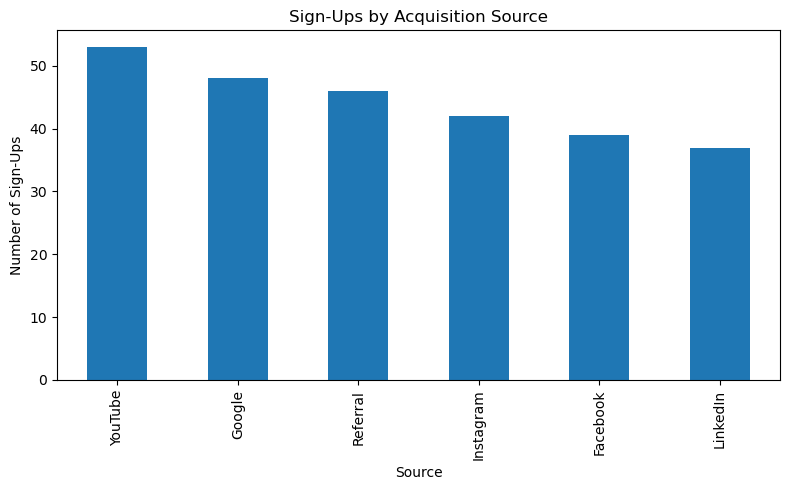

In [75]:
import matplotlib.pyplot as plt
signups_by_source = df["source"].value_counts()

plt.figure(figsize=(8,5))
signups_by_source.plot(kind="bar")

plt.title("Sign-Ups by Acquisition Source")
plt.xlabel("Source")
plt.ylabel("Number of Sign-Ups")

plt.tight_layout()

plt.show()

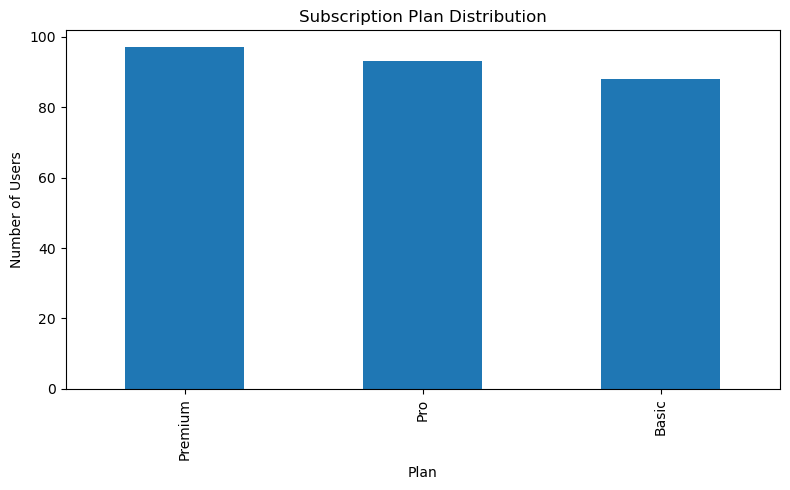

In [76]:
plan_distribution = df["plan_selected"].value_counts()

plt.figure(figsize=(8,5))
plan_distribution.plot(kind="bar")

plt.title("Subscription Plan Distribution")
plt.xlabel("Plan")
plt.ylabel("Number of Users")

plt.tight_layout()
#plt.savefig("../visuals/plan_distribution.png")

plt.show()

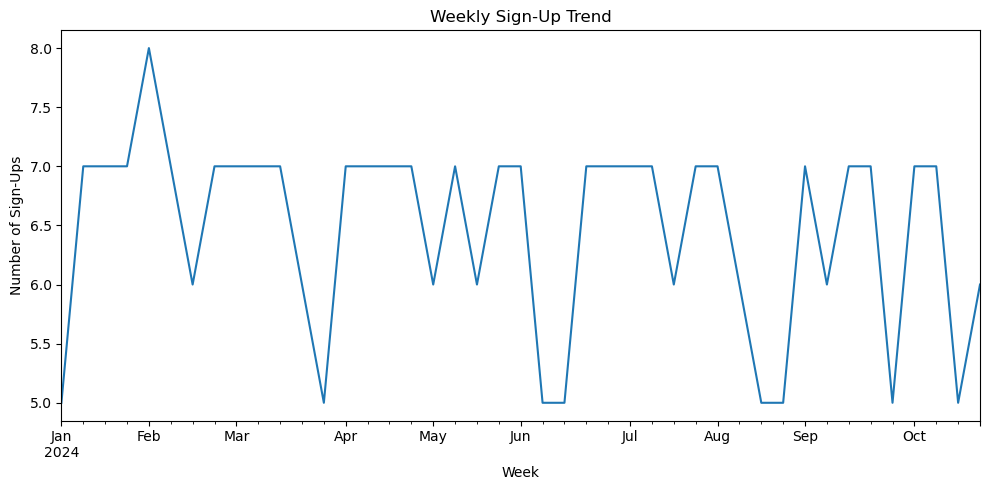

In [77]:
weekly_signups = df.groupby(df["signup_date"].dt.to_period("W")).size()

plt.figure(figsize=(10,5))
weekly_signups.plot()

plt.title("Weekly Sign-Up Trend")
plt.xlabel("Week")
plt.ylabel("Number of Sign-Ups")

plt.tight_layout()
#plt.savefig("../visuals/weekly_signup_trend.png")

plt.show()